### Import Packages

In [5]:
# General data handling
import pandas as pd
import numpy as np
import duckdb

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Sentence Transformers
import transformers
from sentence_transformers import SentenceTransformer

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV

# Validation 
from sklearn.model_selection import (StratifiedKFold, GridSearchCV, RandomizedSearchCV,
                                     cross_validate, cross_val_predict, train_test_split)
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             PrecisionRecallDisplay,
                             auc, make_scorer, recall_score, precision_score)

# Other helpers
from scipy.stats import loguniform
import joblib
from tqdm import tqdm

### Load the data

In [6]:
# Connect to DuckDB database
db = duckdb.connect(database='publications.db')

In [7]:
# Convert raw data to pandas dataframe
data = db.sql("SELECT * FROM publications_raw").df()

In [8]:
# Concatenate title and abstract for input into sentence transformer
data['text'] = data['title'] + ' [SEP] ' + data['abstract']

In [96]:
# inspect data
print(len(data))
data.head()

4815


,id,title,abstract,year,scope,pillar,research_category,text
0,pub.1192791591,Mushroom: an emerging source for next generati...,"Background: In recent years, plant-based and a...",2025,in,PB,Ingredient optimisation,Mushroom: an emerging source for next generati...
1,pub.1187762379,Plant-Based Alternatives to Meat Products,Animal proteins have been used in the formulat...,2025,in,PB,Other,Plant-Based Alternatives to Meat Products [SEP...
2,pub.1193391974,Influence of processing on protein quality and...,While meat is an established source of high-qu...,2025,in,PB,Ingredient optimisation,Influence of processing on protein quality and...
3,pub.1188899046,Solid State Fermentation—A Promising Approach ...,The increasing demand for sustainable dietary ...,2025,in,F,Other,Solid State Fermentation—A Promising Approach ...
4,pub.1193352421,"Physicochemical, Microbiological and Sensory E...",The bioactive properties of a phenolic extract...,2025,in,PB,End product formulation,"Physicochemical, Microbiological and Sensory E..."


### Sentence Transformer to generate text embeddings

In [9]:
# Load model
model = SentenceTransformer('allenai/scibert_scivocab_uncased')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11779.09it/s]
[transformers] BertModel LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [10]:
# Check token lengths
# Access tokenizer from within the loaded SentenceTransformer
tokenizer = model.tokenizer

# Count tokens for each text (title + abstract combined)
token_count = data['text'].apply(
    lambda x: len(tokenizer.encode(x, add_special_tokens=True))
)

# Summary statistics
print(token_count.describe())
print(f"\nTexts exceeding 512 tokens: {(token_count > 512).sum()} "
      f"({(token_count > 512).mean():.1%})")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (549 > 512). Running this sequence through the model will result in indexing errors


count    4815.000000
mean      345.041952
std       110.430074
min        30.000000
25%       277.000000
50%       331.000000
75%       392.000000
max      1671.000000
Name: text, dtype: float64

Texts exceeding 512 tokens: 297 (6.2%)


In [ ]:
# Visualise distribution
token_count.hist(bins=50, edgecolor='black')
plt.axvline(512, color='red', linestyle='--', label='Token limit (512)')
plt.xlabel('Token count')
plt.ylabel('Number of publications')
plt.title('Token length distribution')
plt.legend()
plt.show()

In [14]:
# Leave entries with excessively long token counts for now, they will be automatically truncated by the model
# Store information about truncation in the dataset to check these entries later
data['truncated'] = token_count > 512

0       False
1       False
2       False
3       False
4       False
        ...  
4810    False
4811    False
4812    False
4813    False
4814    False
Name: truncated, Length: 4815, dtype: bool


In [12]:
# Create combined label for stratification
data['stratify_label'] = data['pillar'] + '-' + data['research_category']

# For labels that are too rare, only group them by research category across pillars 
counts = data['stratify_label'].value_counts()
rc = counts.index[counts < 4].str.split('-').str[1].unique()

data['stratify_label'] = data['stratify_label'].where(
    ~data['research_category'].isin(rc), data['stratify_label'].str.split('-').str[1]
)

In [13]:
data['stratify_label'].value_counts()

stratify_label
NA-NA                          3773
PB-Ingredient optimisation      283
End product formulation         148
Consumer & market research      129
Texturization methods            65
PB-Health & nutrition            46
Food safety & quality            45
F-Ingredient optimisation        44
PB-Crop development              37
Bioprocess design                33
F-Feedstocks                     29
CC-Other                         19
PB-Impact assessments            18
CC-Ingredient optimisation       17
F-Strain development             16
CM-Scaffolding                   14
CM-Other                         13
PB-Other                         11
PB-Strain development            11
F-Other                          10
F-Health & nutrition             10
CM-Cell culture media             9
CM-Cell line development          8
CC-Health & nutrition             7
F-Impact assessments              6
CC-Impact assessments             5
CM-Impact assessments             5
F-Target mole

In [ ]:
# add the truncated label to database
db.sql("ALTER TABLE publications_raw ADD COLUMN IF NOT EXISTS truncated BOOLEAN")

db.register("df_temp", data)  
db.sql("""
    UPDATE publications_raw
    SET truncated = df_temp.truncated
    FROM df_temp
    WHERE publications_raw.id = df_temp.id
""")

In [17]:
# add the stratify_label to database
db.sql("ALTER TABLE publications_raw ADD COLUMN IF NOT EXISTS stratify_label TEXT")

db.register("df_temp", data)  
db.sql("""
    UPDATE publications_raw
    SET stratify_label = df_temp.stratify_label
    FROM df_temp
    WHERE publications_raw.id = df_temp.id
""")

In [18]:
db.sql("DESCRIBE publications_raw").show()

┌───────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│    column_name    │ column_type │  null   │   key   │ default │  extra  │
│      varchar      │   varchar   │ varchar │ varchar │ varchar │ varchar │
├───────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ id                │ VARCHAR     │ NO      │ PRI     │ NULL    │ NULL    │
│ title             │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ abstract          │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ year              │ INTEGER     │ YES     │ NULL    │ NULL    │ NULL    │
│ scope             │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ pillar            │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ research_category │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ truncated         │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ stratify_label    │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
└───────────

In [109]:
# for testing: subset data
# the following line of code subsets randomly
# data_sub = data.sample(n=500, random_state=42)

# but we want the classes to be represented somewhat balanced in the subset
data_sub = data.groupby('stratify_label').sample(frac=0.1, replace=False, random_state=42)

# manually add entries for labels with only 1 entry
# find labels with only 1 sample
rare = data_sub['stratify_label'].value_counts()
rare = rare[rare < 2].index

# Add 1 more from unsampled rows for those labels
extra = (
    data[~data.index.isin(data_sub.index) & data['stratify_label'].isin(rare)]
    .groupby('stratify_label')
    .sample(n=1, random_state=42)
)

# add together
data_sub = pd.concat([data_sub, extra])

print(len(data_sub))
print(data_sub['stratify_label'].value_counts())

490
stratify_label
NA-NA                         377
PB-Ingredient optimisation     28
End product formulation        15
Consumer & market research     13
Texturization methods           6
PB-Health & nutrition           5
F-Ingredient optimisation       4
Food safety & quality           4
PB-Crop development             4
Bioprocess design               3
F-Feedstocks                    3
CC-Health & nutrition           2
CC-Ingredient optimisation      2
CC-Other                        2
CM-Cell culture media           2
CM-Cell line development        2
CM-Other                        2
CM-Scaffolding                  2
F-Health & nutrition            2
F-Impact assessments            2
F-Other                         2
F-Strain development            2
PB-Impact assessments           2
PB-Other                        2
PB-Strain development           2
Name: count, dtype: int64


In [ ]:
# save to database to enable loading later
# db.sql("CREATE OR REPLACE TABLE publications_subset AS SELECT * FROM data_sub")

In [111]:
# Encode — returns numpy array of shape (n_publications, 768)
embeddings = model.encode(
    data_sub['text'].tolist(),
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)

Batches: 100%|██████████| 16/16 [05:03<00:00, 18.95s/it]


In [112]:
# save embeddings
np.save('scibert_embeddings_test.npy', embeddings)

### Split data into train and test data

In [19]:
# Load embeddings 
embeddings = np.load('scibert_embeddings.npy')

# Load subsetted data
# data_sub = db.sql("SELECT * FROM publications_subset").df()

In [146]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    embeddings, data,
    test_size=0.2,
    random_state=42,
    stratify=data['stratify_label']
)


### Classification of in/out of scope

In [147]:
# Convert scope to binary integer class
y_train_scope = (y_train['scope'] == 'in').astype(int)
y_test_scope  = (y_test['scope']  == 'in').astype(int)

#### Test hyperparameters and models

In [148]:
# Set up validation metrics
## specificity isn't natively integrated, define function:
specificity_scorer = make_scorer(recall_score, pos_label=0)
npv_scorer = make_scorer(precision_score, pos_label=0)

scoring = {
    'precision':    'precision', # = TP / (TP + FP)
    'recall':       'recall', # = sensitivity = TP / (TP + FN)
    'specificity':  specificity_scorer, # = TN / (TN + FP)
    'npv':          npv_scorer, # = TN / (TN + FN)
    'f1':           'f1' # 2 × (precision × recall) / (precision + recall)
}

In [152]:
# Test hyperparameters of Logistic Regression model using cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'C': [0.1, 1, 10, 100, 1000],
    'class_weight': ['balanced', None],
    'penalty': [None, 'l2']
}

grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
                    param_grid, cv=cv, scoring=scoring, refit='npv', n_jobs=-1)
grid.fit(X_train, y_train_scope)
print(grid.best_params_)

{'C': 10, 'class_weight': 'balanced', 'penalty': 'l2'}


c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [153]:
# save results to data frame
lr_grid = pd.DataFrame(grid.cv_results_)

cols = ['param_C', 'param_penalty',  
        'mean_test_precision', 'std_test_precision','mean_test_recall', 'std_test_recall', 'mean_test_f1', 'std_test_f1',
        'mean_test_specificity', 'std_test_specificity', 'mean_test_npv', 'std_test_npv']
lr_grid[cols]

## class_weight is clearly better with class_weight = 'balanced'
## the best C value depends on the metric --> 10 or 100

lr_grid[cols].to_csv('LR_grid.csv')

In [195]:
# Test hyperparameters of Support Vector Classification model
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'estimator__C':     [1, 10, 100, 1000],
    'estimator__gamma': [0.001, 0.01],
    'estimator__kernel': ['linear', 'rbf']
}

# CalibratedClasssifierCV wrapper to get calibrated probabilities
calibrated_svc = CalibratedClassifierCV(
    SVC(class_weight='balanced'),
    cv=cv,
    ensemble=False
)

grid = GridSearchCV(calibrated_svc, param_grid, cv=cv, scoring=scoring, refit='f1', n_jobs=-1)
grid.fit(X_train, y_train_scope)
print(grid.best_params_)

{'estimator__C': 10, 'estimator__gamma': 0.001, 'estimator__kernel': 'linear'}


In [ ]:
# save results to data frame
svc_grid = pd.DataFrame(grid.cv_results_)

cols = ['param_estimator__C', 'param_estimator__gamma', 'param_estimator__kernel', 
        'mean_test_precision', 'std_test_precision','mean_test_recall', 'std_test_recall', 'mean_test_f1', 'std_test_f1',
        'mean_test_specificity', 'std_test_specificity', 'mean_test_npv', 'std_test_npv']
svc_grid[cols]

svc_grid[cols].to_csv('SVC_grid.csv')

## best results for NPV, Recall and F1
## C=10, kernel='linear' (gamma doesn't apply for linear kernel)	

In [197]:
# Test hyperparameters of Multi-Layer Perceptron model
param_dist = {
    'hidden_layer_sizes': [(64,), (128,), (256,), (64, 32), (128, 64), (256, 128)],
    'alpha': loguniform(1e-5, 1e-2),
    'learning_rate_init': loguniform(1e-4, 1e-1)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = RandomizedSearchCV(
    MLPClassifier(early_stopping=True, random_state=42),
    param_distributions=param_dist,
    n_iter=50,
    scoring=scoring,
    refit='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42,
)

grid.fit(X_train, y_train_scope)
print(grid.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
{'alpha': np.float64(0.006584106160121612), 'hidden_layer_sizes': (256, 128), 'learning_rate_init': np.float64(0.06025271171095385)}


In [ ]:
# save results to data frame
mlp_grid = pd.DataFrame(grid.cv_results_)

cols = ['param_hidden_layer_sizes', 'param_learning_rate_init', 
        'param_alpha', 
        'mean_test_precision', 'std_test_precision','mean_test_recall', 'std_test_recall', 'mean_test_f1', 'std_test_f1',
        'mean_test_specificity', 'std_test_specificity', 'mean_test_npv', 'std_test_npv']

mlp_grid[cols].to_csv('MLP_grid.csv')

## Best results for NPV & Recall (and third for F1)
## hidden_layer_sizes= (256,128), learning_rate_init=0.045882, alpha=0.001545

### Validate models with selected hyperparameters

### Logistic Regression

#### Cross validation

In [291]:
# Logistic Regression with C=10 and penalty='l2'
clf = LogisticRegression(max_iter=1000, class_weight='balanced', C=10, penalty='l2', random_state=42)
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [292]:
# fit model
clf.fit(X_train, y_train_scope)

# Run cross-validation on subset of data
lr_results = cross_validate(clf, X_train, y_train_scope, cv=cv, scoring=scoring)

c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Public\minicond

In [293]:
for metric in ['precision', 'recall', 'specificity', 'npv', 'f1']:
    scores = lr_results[f'test_{metric}']
    print(f"{metric:12s}: {scores.mean():.3f} ± {scores.std():.3f}")

precision   : 0.593 ± 0.018
recall      : 0.828 ± 0.022
specificity : 0.843 ± 0.011
npv         : 0.947 ± 0.006
f1          : 0.691 ± 0.017


In [294]:
# Get prediction (out of fold)
lr_probs = cross_val_predict(clf, X_train, y_train_scope, 
                              cv=cv, method='predict_proba')[:, 1]
lr_preds = (lr_probs >= 0.5).astype(int)  # binary at default threshold


c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Public\minicond

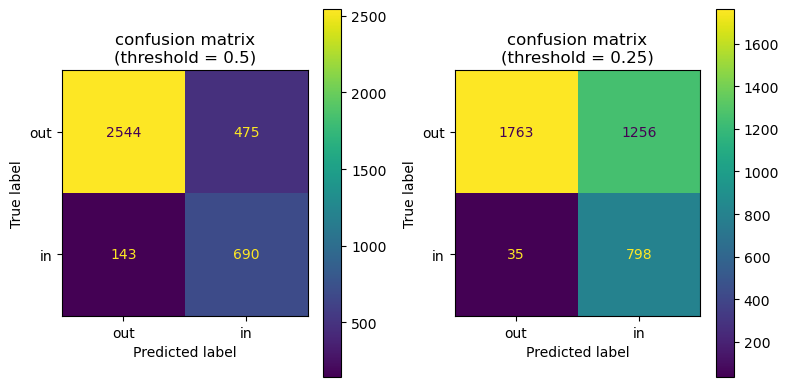

In [295]:
lr_preds_05 = (lr_probs >= 0.5).astype(int)  # binary at default threshold
lr_preds_025 = (lr_probs >= 0.25).astype(int)  # binary at default threshold

# Plot confusion matrix
fig, ax = plt.subplots(1,2, figsize=(8,4))

ConfusionMatrixDisplay(
    confusion_matrix(y_train_scope, lr_preds_05),
    display_labels=['out', 'in']
).plot(ax=ax[0])
ax[0].set_title('confusion matrix\n(threshold = 0.5)')

ConfusionMatrixDisplay(
    confusion_matrix(y_train_scope, lr_preds_025),
    display_labels=['out', 'in']
).plot(ax=ax[1])
ax[1].set_title('confusion matrix\n(threshold = 0.25)')


plt.tight_layout()
plt.show()

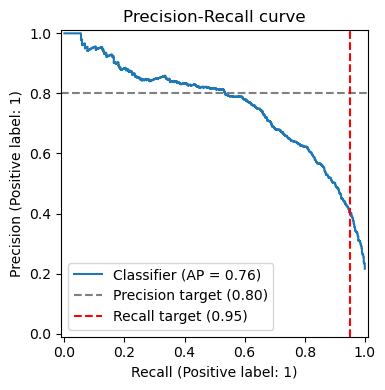

In [296]:
# Plot precision-recall curve
fig, ax = plt.subplots(figsize=(4,4))
PrecisionRecallDisplay.from_predictions(
    y_train_scope, lr_probs, ax=ax
)
ax.axhline(0.80, color='grey',  linestyle='--', label='Precision target (0.80)')
ax.axvline(0.95, color='red',   linestyle='--', label='Recall target (0.95)')
ax.set_title('Precision-Recall curve')
ax.legend()
plt.tight_layout()
plt.show()

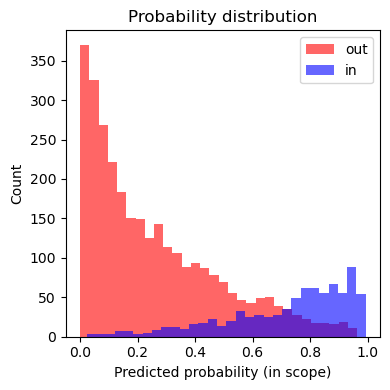

In [297]:
fig, ax = plt.subplots(figsize=(4,4))
ax.hist(lr_probs[y_train_scope == 0], bins=30, alpha=0.6, 
        color='red',  label='out')
ax.hist(lr_probs[y_train_scope == 1], bins=30, alpha=0.6, 
        color='blue', label='in')
ax.set_xlabel('Predicted probability (in scope)')
ax.set_ylabel('Count')
ax.set_title('Probability distribution')
ax.legend()
plt.tight_layout()
plt.show()

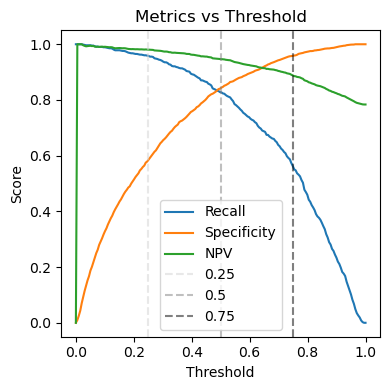

In [299]:
# Plot recall, specificity and npv against different thresholds
thresholds_range = np.linspace(0, 1, 200)

sensitivity = []  # recall / TPR
specificity = []  # TNR
npv         = []  # TN / (TN + FN)

for t in thresholds_range:
    y_pred = (lr_probs >= t).astype(int)
    
    TP = ((y_pred == 1) & (y_train_scope == 1)).sum()
    TN = ((y_pred == 0) & (y_train_scope == 0)).sum()
    FP = ((y_pred == 1) & (y_train_scope == 0)).sum()
    FN = ((y_pred == 0) & (y_train_scope == 1)).sum()
    
    sensitivity.append(TP / (TP + FN) if (TP + FN) > 0 else 0)
    specificity.append(TN / (TN + FP) if (TN + FP) > 0 else 0)
    npv.append(        TN / (TN + FN) if (TN + FN) > 0 else 0)

fig, ax = plt.subplots(figsize=(4, 4))

# Plot 1: all three metrics vs threshold
ax.plot(thresholds_range, sensitivity, label='Recall')
ax.plot(thresholds_range, specificity, label='Specificity')
ax.plot(thresholds_range, npv,         label='NPV')
ax.axvline(0.25, color='lightgrey', linestyle='--', alpha=0.5, label='0.25')
ax.axvline(0.5, color='grey', linestyle='--', alpha=0.5, label='0.5')
ax.axvline(0.75, color='black', linestyle='--', alpha=0.5, label='0.75')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Metrics vs Threshold')
ax.legend()

plt.tight_layout()
#plt.savefig('threshold_curves.png', dpi=150, bbox_inches='tight')
plt.show()

#### Test data

In [300]:
# Test data
lr_test_pred = clf.predict(X_test)
lr_test_proba = clf.predict_proba(X_test)[:, 1]

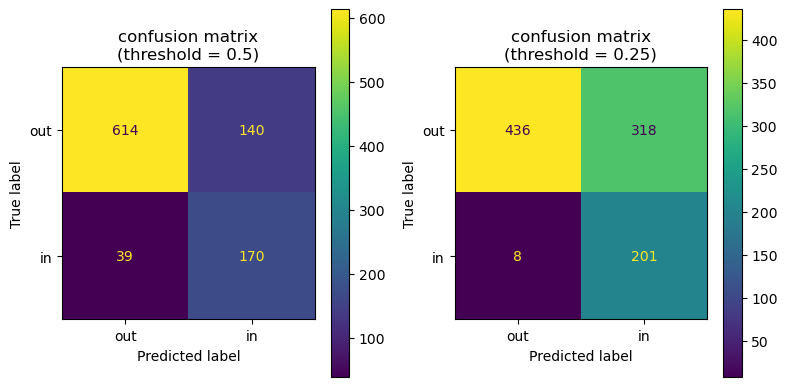

In [301]:
lr_test_preds_05 = (lr_test_proba >= 0.5).astype(int)  # binary at default threshold
lr_test_preds_025 = (lr_test_proba >= 0.25).astype(int)  # binary at default threshold

# Plot confusion matrix
fig, ax = plt.subplots(1,2, figsize=(8,4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test_scope, lr_test_preds_05),
    display_labels=['out', 'in']
).plot(ax=ax[0])
ax[0].set_title('confusion matrix\n(threshold = 0.5)')

ConfusionMatrixDisplay(
    confusion_matrix(y_test_scope, lr_test_preds_025),
    display_labels=['out', 'in']
).plot(ax=ax[1])
ax[1].set_title('confusion matrix\n(threshold = 0.25)')


plt.tight_layout()
plt.savefig('Plots/SciBERT_LR_ConfusionMatrix.png', dpi=150, bbox_inches='tight')
plt.show()

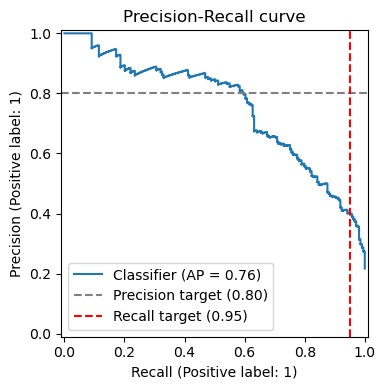

In [302]:
# Plot precision-recall curve
fig, ax = plt.subplots(figsize=(4,4))
PrecisionRecallDisplay.from_predictions(
    y_test_scope, lr_test_proba, ax=ax
)
ax.axhline(0.80, color='grey',  linestyle='--', label='Precision target (0.80)')
ax.axvline(0.95, color='red',   linestyle='--', label='Recall target (0.95)')
ax.set_title('Precision-Recall curve')
ax.legend()
plt.tight_layout()
plt.savefig('Plots/SciBERT_LR_Precision-Recall.png', dpi=150, bbox_inches='tight')
plt.show()

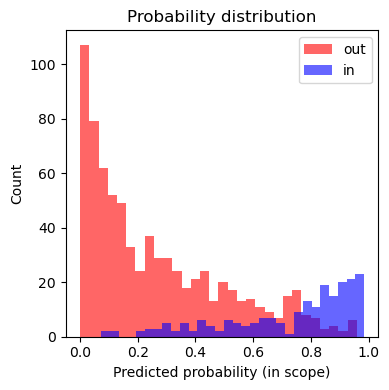

In [303]:
fig, ax = plt.subplots(figsize=(4,4))
ax.hist(lr_test_proba[y_test_scope == 0], bins=30, alpha=0.6, 
        color='red',  label='out')
ax.hist(lr_test_proba[y_test_scope == 1], bins=30, alpha=0.6, 
        color='blue', label='in')
ax.set_xlabel('Predicted probability (in scope)')
ax.set_ylabel('Count')
ax.set_title('Probability distribution')
ax.legend()
plt.tight_layout()
plt.savefig('Plots/SciBERT_LR_ProbabilityDistribution.png', dpi=150, bbox_inches='tight')
plt.show()

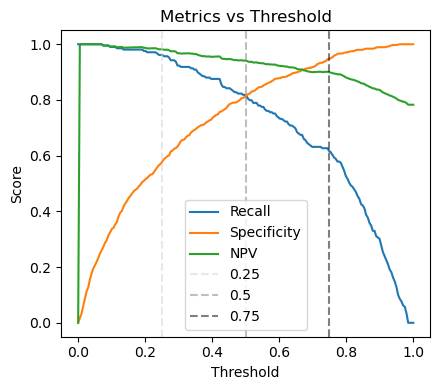

In [305]:
# Plot recall, specificity and npv against different thresholds
thresholds_range = np.linspace(0, 1, 200)

sensitivity = []  # recall / TPR
specificity = []  # TNR
npv         = []  # TN / (TN + FN)

for t in thresholds_range:
    test_pred = (lr_test_proba >= t).astype(int)
    
    TP = ((test_pred == 1) & (y_test_scope == 1)).sum()
    TN = ((test_pred == 0) & (y_test_scope == 0)).sum()
    FP = ((test_pred == 1) & (y_test_scope == 0)).sum()
    FN = ((test_pred == 0) & (y_test_scope == 1)).sum()
    
    sensitivity.append(TP / (TP + FN) if (TP + FN) > 0 else 0)
    specificity.append(TN / (TN + FP) if (TN + FP) > 0 else 0)
    npv.append(        TN / (TN + FN) if (TN + FN) > 0 else 0)

fig, ax = plt.subplots(figsize=(4.5, 4))

# Plot 1: all three metrics vs threshold
ax.plot(thresholds_range, sensitivity, label='Recall')
ax.plot(thresholds_range, specificity, label='Specificity')
ax.plot(thresholds_range, npv,         label='NPV')
ax.axvline(0.25, color='lightgrey', linestyle='--', alpha=0.5, label='0.25')
ax.axvline(0.5, color='grey', linestyle='--', alpha=0.5, label='0.5')
ax.axvline(0.75, color='black', linestyle='--', alpha=0.5, label='0.75')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Metrics vs Threshold')
ax.legend()

plt.tight_layout()
plt.savefig('Plots/SciBERT_LR_MetricsThreshold.png', dpi=150, bbox_inches='tight')
plt.show()

In [313]:
# Metrics for threshold T
T = 0.25
pred = (lr_test_proba >= T).astype(int)
    
TP = ((pred == 1) & (y_test_scope == 1)).sum()
TN = ((pred == 0) & (y_test_scope == 0)).sum()
FP = ((pred == 1) & (y_test_scope == 0)).sum()
FN = ((pred == 0) & (y_test_scope == 1)).sum()

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)
npv = TN / (TN + FN) 

p, c = np.unique(pred, return_counts=True)

print(f"With a threshold of {T}, we remove {round(c[0] / (c[0] + c[1]) * 100, 2)}% of all entries and loose ~{round(FN / len(pred) * 100,2)}% of in scope cases.")
print(f"Sensitivity: {sensitivity}, Specificity: {specificity}, NPV: {npv}")

With a threshold of 0.25, we remove 46.11% of all entries and loose ~0.83% of in scope cases.
Sensitivity: 0.9617224880382775, Specificity: 0.5782493368700266, NPV: 0.9819819819819819


#### Manual check of borderline cases

In [126]:
borderline = [
    "pub.1124225534", "pub.1124559012", "pub.1124752776", "pub.1125171104",
    "pub.1125711840", "pub.1125900690", "pub.1126016358", "pub.1126776207",
    "pub.1127784762", "pub.1128699237", "pub.1128910615", "pub.1128979198",
    "pub.1129074092", "pub.1129500680", "pub.1129501629", "pub.1129666565",
    "pub.1129921272", "pub.1130005418", "pub.1130094430", "pub.1130433231",
    "pub.1130539219", "pub.1131172589", "pub.1131480945", "pub.1131844732",
    "pub.1131885381"
]

In [326]:
# Combine tables with probabilities and predictions for threshold T
T = 0.25

d_train = y_train.copy()
d_train['proba'] = lr_probs
d_train[f'pred_{T}'] = (d_train['proba'] >= T).astype(int)

d_test = y_test.copy()
d_test['proba'] = lr_test_proba
d_test[f'pred_{T}'] = (d_test['proba'] >= T).astype(int)

d = pd.concat([d_train, d_test])

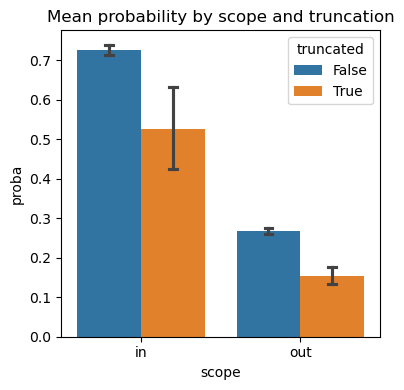

In [321]:
# Check wether truncation during embedding makes a difference
d.groupby(['scope', 'truncated'])['proba'].mean()

fig, ax = plt.subplots(figsize=(4, 4))
sns.barplot(data=d, x='scope', y='proba', hue='truncated',  capsize=0.1, ax=ax)
ax.set_title('Mean probability by scope and truncation')
plt.tight_layout()
plt.savefig('Plots/SciBERT_LR_T025_truncation.png', dpi=150, bbox_inches='tight')
plt.show()

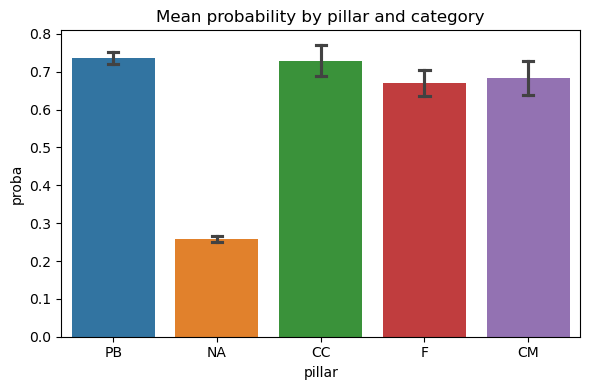

In [322]:
# Check whether different pillars/categories make a difference
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=d, x='pillar', y='proba', hue='pillar', capsize=0.1, ax=ax)
ax.set_title('Mean probability by pillar and category')
plt.tight_layout()
plt.savefig('Plots/SciBERT_LR_Probabilities_Pillar.png', dpi=150, bbox_inches='tight')
plt.show()

In [337]:
lr_fn = d[(d['scope']=='in')  & (d['pred_0.25']==0)]

### SVC

#### Cross validation

In [222]:
# Logistic Regression with C=10 and penalty='l2'
svc = CalibratedClassifierCV(SVC(max_iter=1000, class_weight='balanced', C=10, random_state=42, kernel='linear'))
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [224]:
# fit model
svc.fit(X_train, y_train_scope)

# Run cross-validation on subset of data
results_svc = cross_validate(svc, X_train, y_train_scope, cv=cv, scoring=scoring)

c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-

In [225]:
for metric in ['precision', 'recall', 'specificity', 'npv', 'f1']:
    scores = results_svc[f'test_{metric}']
    print(f"{metric:12s}: {scores.mean():.3f} ± {scores.std():.3f}")

precision   : 0.771 ± 0.053
recall      : 0.599 ± 0.042
specificity : 0.951 ± 0.013
npv         : 0.896 ± 0.011
f1          : 0.674 ± 0.044


In [226]:
# Get prediction (out of fold)
svc_probs = cross_val_predict(svc, X_train, y_train_scope, 
                              cv=cv, method='predict_proba')[:, 1]
svc_preds = (svc_probs >= 0.5).astype(int)  # binary at default threshold

c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-

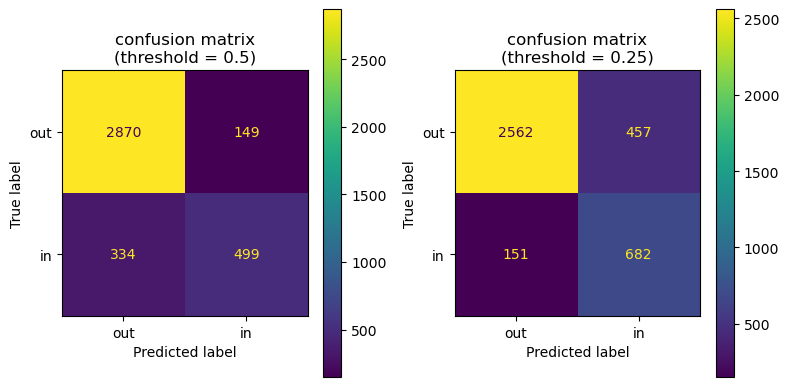

In [227]:
svc_preds_05 = (svc_probs >= 0.5).astype(int)  # binary at default threshold
svc_preds_025 = (svc_probs >= 0.25).astype(int)  # binary at default threshold

# Plot confusion matrix
fig, ax = plt.subplots(1,2, figsize=(8,4))

ConfusionMatrixDisplay(
    confusion_matrix(y_train_scope, svc_preds_05),
    display_labels=['out', 'in']
).plot(ax=ax[0])
ax[0].set_title('confusion matrix\n(threshold = 0.5)')

ConfusionMatrixDisplay(
    confusion_matrix(y_train_scope, svc_preds_025),
    display_labels=['out', 'in']
).plot(ax=ax[1])
ax[1].set_title('confusion matrix\n(threshold = 0.25)')


plt.tight_layout()
plt.show()

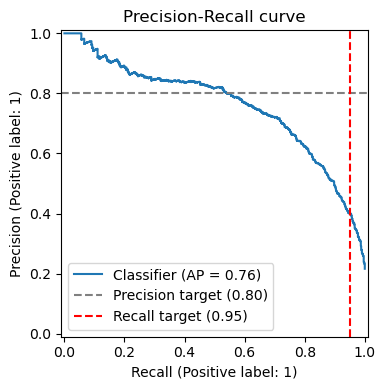

In [228]:
# Plot precision-recall curve
fig, ax = plt.subplots(figsize=(4,4))
PrecisionRecallDisplay.from_predictions(
    y_train_scope, svc_probs, ax=ax
)
ax.axhline(0.80, color='grey',  linestyle='--', label='Precision target (0.80)')
ax.axvline(0.95, color='red',   linestyle='--', label='Recall target (0.95)')
ax.set_title('Precision-Recall curve')
ax.legend()
plt.tight_layout()
plt.show()

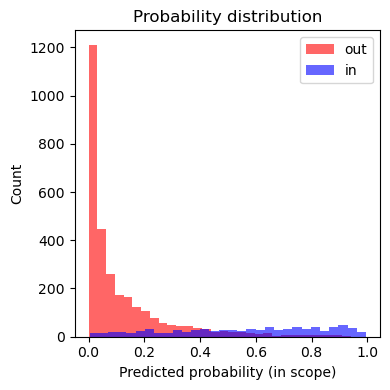

In [229]:
fig, ax = plt.subplots(figsize=(4,4))
ax.hist(svc_probs[y_train_scope == 0], bins=30, alpha=0.6, 
        color='red',  label='out')
ax.hist(svc_probs[y_train_scope == 1], bins=30, alpha=0.6, 
        color='blue', label='in')
ax.set_xlabel('Predicted probability (in scope)')
ax.set_ylabel('Count')
ax.set_title('Probability distribution')
ax.legend()
plt.tight_layout()
plt.show()

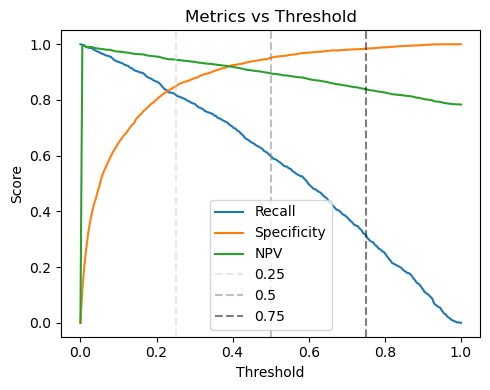

In [230]:
# Plot recall, specificity and npv against different thresholds
thresholds_range = np.linspace(0, 1, 200)

sensitivity = []  # recall / TPR
specificity = []  # TNR
npv         = []  # TN / (TN + FN)

for t in thresholds_range:
    y_pred = (svc_probs >= t).astype(int)
    
    TP = ((y_pred == 1) & (y_train_scope == 1)).sum()
    TN = ((y_pred == 0) & (y_train_scope == 0)).sum()
    FP = ((y_pred == 1) & (y_train_scope == 0)).sum()
    FN = ((y_pred == 0) & (y_train_scope == 1)).sum()
    
    sensitivity.append(TP / (TP + FN) if (TP + FN) > 0 else 0)
    specificity.append(TN / (TN + FP) if (TN + FP) > 0 else 0)
    npv.append(        TN / (TN + FN) if (TN + FN) > 0 else 0)

fig, ax = plt.subplots(figsize=(5, 4))

# Plot 1: all three metrics vs threshold
ax.plot(thresholds_range, sensitivity, label='Recall')
ax.plot(thresholds_range, specificity, label='Specificity')
ax.plot(thresholds_range, npv,         label='NPV')
ax.axvline(0.25, color='lightgrey', linestyle='--', alpha=0.5, label='0.25')
ax.axvline(0.5, color='grey', linestyle='--', alpha=0.5, label='0.5')
ax.axvline(0.75, color='black', linestyle='--', alpha=0.5, label='0.75')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Metrics vs Threshold')
ax.legend()

plt.tight_layout()
#plt.savefig('threshold_curves.png', dpi=150, bbox_inches='tight')
plt.show()

#### Test data

In [237]:
# Test data
svc_test_pred = svc.predict(X_test)
svc_test_proba = svc.predict_proba(X_test)[:, 1]

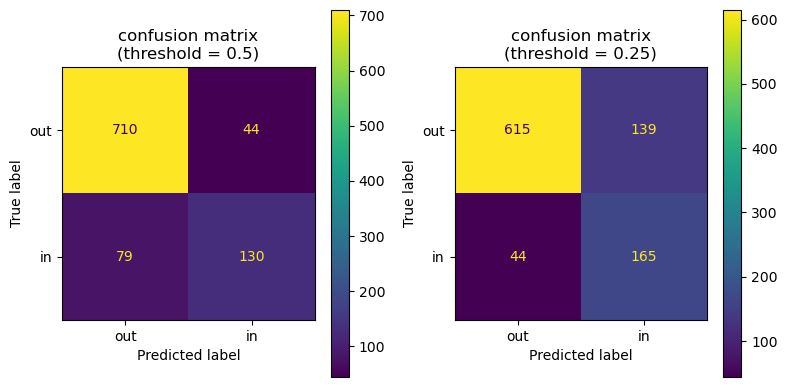

In [239]:
svc_test_preds_05 = (svc_test_proba >= 0.5).astype(int)  # binary at default threshold
svc_test_preds_025 = (svc_test_proba >= 0.25).astype(int)  # binary at default threshold

# Plot confusion matrix
fig, ax = plt.subplots(1,2, figsize=(8,4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test_scope, svc_test_preds_05),
    display_labels=['out', 'in']
).plot(ax=ax[0])
ax[0].set_title('confusion matrix\n(threshold = 0.5)')

ConfusionMatrixDisplay(
    confusion_matrix(y_test_scope, svc_test_preds_025),
    display_labels=['out', 'in']
).plot(ax=ax[1])
ax[1].set_title('confusion matrix\n(threshold = 0.25)')


plt.tight_layout()
plt.savefig('Plots/SciBERT_SVC_ConfusionMatrix.png', dpi=150, bbox_inches='tight')
plt.show()

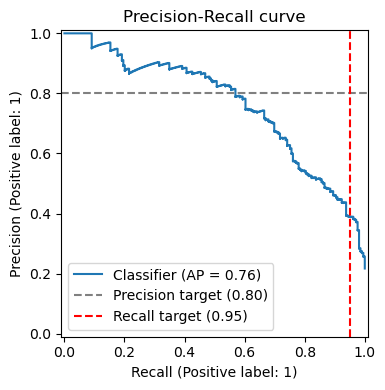

In [242]:
# Plot precision-recall curve
fig, ax = plt.subplots(figsize=(4,4))
PrecisionRecallDisplay.from_predictions(
    y_test_scope, svc_test_proba, ax=ax
)
ax.axhline(0.80, color='grey',  linestyle='--', label='Precision target (0.80)')
ax.axvline(0.95, color='red',   linestyle='--', label='Recall target (0.95)')
ax.set_title('Precision-Recall curve')
ax.legend()
plt.tight_layout()
plt.savefig('Plots/SciBERT_SVC_Precision-Recall.png', dpi=150, bbox_inches='tight')
plt.show()

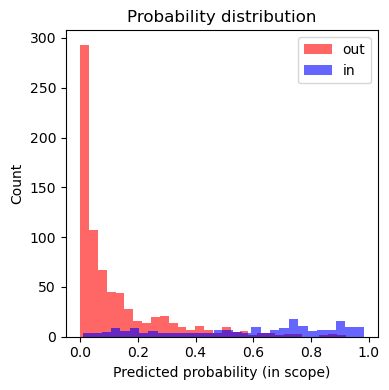

In [243]:
fig, ax = plt.subplots(figsize=(4,4))
ax.hist(svc_test_proba[y_test_scope == 0], bins=30, alpha=0.6, 
        color='red',  label='out')
ax.hist(svc_test_proba[y_test_scope == 1], bins=30, alpha=0.6, 
        color='blue', label='in')
ax.set_xlabel('Predicted probability (in scope)')
ax.set_ylabel('Count')
ax.set_title('Probability distribution')
ax.legend()
plt.tight_layout()
plt.savefig('Plots/SciBERT_SVC_ProbabilityDistribution.png', dpi=150, bbox_inches='tight')
plt.show()

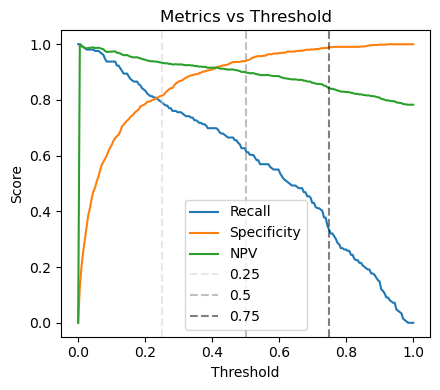

In [306]:
# Plot recall, specificity and npv against different thresholds
thresholds_range = np.linspace(0, 1, 200)

sensitivity = []  # recall / TPR
specificity = []  # TNR
npv         = []  # TN / (TN + FN)

for t in thresholds_range:
    test_pred = (svc_test_proba >= t).astype(int)
    
    TP = ((test_pred == 1) & (y_test_scope == 1)).sum()
    TN = ((test_pred == 0) & (y_test_scope == 0)).sum()
    FP = ((test_pred == 1) & (y_test_scope == 0)).sum()
    FN = ((test_pred == 0) & (y_test_scope == 1)).sum()
    
    sensitivity.append(TP / (TP + FN) if (TP + FN) > 0 else 0)
    specificity.append(TN / (TN + FP) if (TN + FP) > 0 else 0)
    npv.append(        TN / (TN + FN) if (TN + FN) > 0 else 0)

fig, ax = plt.subplots(figsize=(4.5, 4))

# Plot 1: all three metrics vs threshold
ax.plot(thresholds_range, sensitivity, label='Recall')
ax.plot(thresholds_range, specificity, label='Specificity')
ax.plot(thresholds_range, npv,         label='NPV')
ax.axvline(0.25, color='lightgrey', linestyle='--', alpha=0.5, label='0.25')
ax.axvline(0.5, color='grey', linestyle='--', alpha=0.5, label='0.5')
ax.axvline(0.75, color='black', linestyle='--', alpha=0.5, label='0.75')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Metrics vs Threshold')
ax.legend()

plt.tight_layout()
plt.savefig('Plots/SciBERT_SVC_MetricsThreshold.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Metrics for threshold T
T = 0.075
pred = (svc_test_proba >= T).astype(int)
    
TP = ((pred == 1) & (y_test_scope == 1)).sum()
TN = ((pred == 0) & (y_test_scope == 0)).sum()
FP = ((pred == 1) & (y_test_scope == 0)).sum()
FN = ((pred == 0) & (y_test_scope == 1)).sum()

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)
npv = TN / (TN + FN) 

p, c = np.unique(pred, return_counts=True)

print(f"With a threshold of {T}, we remove {round(c[0] / (c[0] + c[1]) * 100, 2)}% of all entries and loose ~{round(FN / len(pred) * 100,2)}% of in scope cases.")
print(f"Sensitivity: {sensitivity}, Specificity: {specificity}, NPV: {npv}")

With a threshold 0.075, we remove 46.11% of all entries and loose ~0.83% of in scope cases.
Sensitivity: 0.9617224880382775, Specificity: 0.5782493368700266, NPV: 0.9819819819819819


#### Manual check of borderline cases

In [ ]:
borderline = [
    "pub.1124225534", "pub.1124559012", "pub.1124752776", "pub.1125171104",
    "pub.1125711840", "pub.1125900690", "pub.1126016358", "pub.1126776207",
    "pub.1127784762", "pub.1128699237", "pub.1128910615", "pub.1128979198",
    "pub.1129074092", "pub.1129500680", "pub.1129501629", "pub.1129666565",
    "pub.1129921272", "pub.1130005418", "pub.1130094430", "pub.1130433231",
    "pub.1130539219", "pub.1131172589", "pub.1131480945", "pub.1131844732",
    "pub.1131885381"
]

In [338]:
# Combine tables with probabilities and predictions for threshold T
T = 0.075

d_train = y_train.copy()
d_train['proba'] = svc_probs
d_train[f'pred_{T}'] = (d_train['proba'] >= T).astype(int)

d_test = y_test.copy()
d_test['proba'] = svc_test_proba
d_test[f'pred_{T}'] = (d_test['proba'] >= T).astype(int)

d = pd.concat([d_train, d_test])

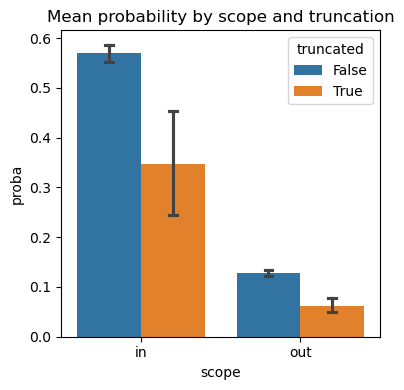

In [318]:
# Check wether truncation during embedding makes a difference
d.groupby(['scope', 'truncated'])['proba'].mean()

fig, ax = plt.subplots(figsize=(4, 4))
sns.barplot(data=d, x='scope', y='proba', hue='truncated',  capsize=0.1, ax=ax)
ax.set_title('Mean probability by scope and truncation')
plt.tight_layout()
plt.savefig('Plots/SciBERT_SVC_T0075_truncation.png', dpi=150, bbox_inches='tight')
plt.show()

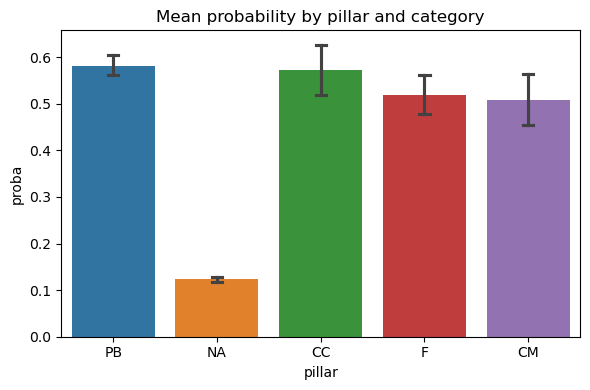

In [319]:
# Check whether different pillars/categories make a difference
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=d, x='pillar', y='proba', hue='pillar', capsize=0.1, ax=ax)
ax.set_title('Mean probability by pillar and category')
plt.tight_layout()
plt.savefig('Plots/SciBERT_SVC_Probabilities_Pillar.png', dpi=150, bbox_inches='tight')
plt.show()

In [340]:
svc_fn = d[(d['scope']=='in')  & (d['pred_0.075']==0)]

### MLP

#### Cross validation

In [267]:
# Logistic Regression with C=10 and penalty='l2'
mlp = MLPClassifier(max_iter=1000, early_stopping=True, hidden_layer_sizes=(256,128), learning_rate_init=0.045882, alpha=0.001545, random_state=42)
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [268]:
# fit model
mlp.fit(X_train, y_train_scope)

# Run cross-validation on subset of data
mlp_results = cross_validate(mlp, X_train, y_train_scope, cv=cv, scoring=scoring)

In [269]:
for metric in ['precision', 'recall', 'specificity', 'npv', 'f1']:
    scores = mlp_results[f'test_{metric}']
    print(f"{metric:12s}: {scores.mean():.3f} ± {scores.std():.3f}")

precision   : 0.762 ± 0.060
recall      : 0.651 ± 0.056
specificity : 0.941 ± 0.022
npv         : 0.907 ± 0.012
f1          : 0.698 ± 0.031


In [270]:
# Get prediction (out of fold)
mlp_probs = cross_val_predict(mlp, X_train, y_train_scope, 
                              cv=cv, method='predict_proba')[:, 1]
mlp_preds = (mlp_probs >= 0.5).astype(int)  # binary at default threshold


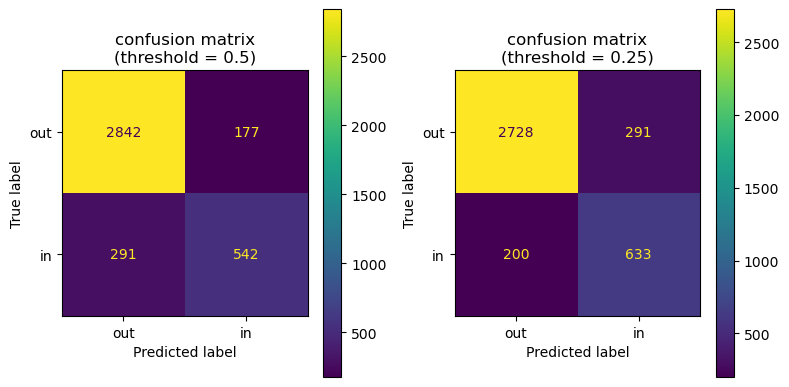

In [271]:
mlp_preds_05 = (mlp_probs >= 0.5).astype(int)  # binary at default threshold
mlp_preds_025 = (mlp_probs >= 0.25).astype(int)  # binary at default threshold

# Plot confusion matrix
fig, ax = plt.subplots(1,2, figsize=(8,4))

ConfusionMatrixDisplay(
    confusion_matrix(y_train_scope, mlp_preds_05),
    display_labels=['out', 'in']
).plot(ax=ax[0])
ax[0].set_title('confusion matrix\n(threshold = 0.5)')

ConfusionMatrixDisplay(
    confusion_matrix(y_train_scope, mlp_preds_025),
    display_labels=['out', 'in']
).plot(ax=ax[1])
ax[1].set_title('confusion matrix\n(threshold = 0.25)')


plt.tight_layout()
plt.show()

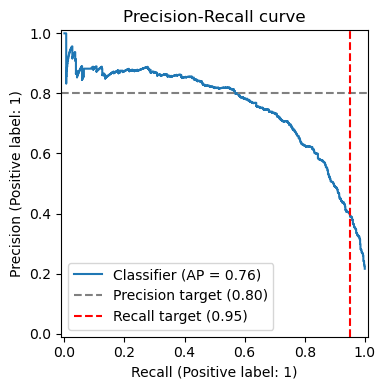

In [272]:
# Plot precision-recall curve
fig, ax = plt.subplots(figsize=(4,4))
PrecisionRecallDisplay.from_predictions(
    y_train_scope, mlp_probs, ax=ax
)
ax.axhline(0.80, color='grey',  linestyle='--', label='Precision target (0.80)')
ax.axvline(0.95, color='red',   linestyle='--', label='Recall target (0.95)')
ax.set_title('Precision-Recall curve')
ax.legend()
plt.tight_layout()
plt.show()

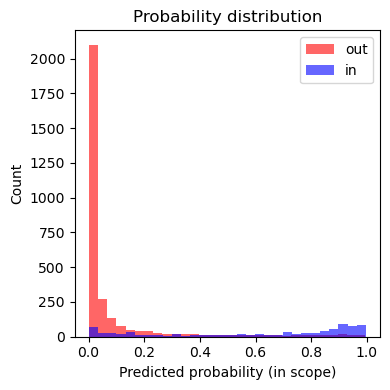

In [273]:
fig, ax = plt.subplots(figsize=(4,4))
ax.hist(mlp_probs[y_train_scope == 0], bins=30, alpha=0.6, 
        color='red',  label='out')
ax.hist(mlp_probs[y_train_scope == 1], bins=30, alpha=0.6, 
        color='blue', label='in')
ax.set_xlabel('Predicted probability (in scope)')
ax.set_ylabel('Count')
ax.set_title('Probability distribution')
ax.legend()
plt.tight_layout()
plt.show()

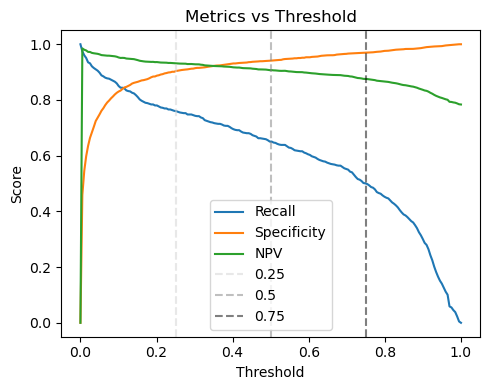

In [274]:
# Plot recall, specificity and npv against different thresholds
thresholds_range = np.linspace(0, 1, 200)

sensitivity = []  # recall / TPR
specificity = []  # TNR
npv         = []  # TN / (TN + FN)

for t in thresholds_range:
    y_pred = (mlp_probs >= t).astype(int)
    
    TP = ((y_pred == 1) & (y_train_scope == 1)).sum()
    TN = ((y_pred == 0) & (y_train_scope == 0)).sum()
    FP = ((y_pred == 1) & (y_train_scope == 0)).sum()
    FN = ((y_pred == 0) & (y_train_scope == 1)).sum()
    
    sensitivity.append(TP / (TP + FN) if (TP + FN) > 0 else 0)
    specificity.append(TN / (TN + FP) if (TN + FP) > 0 else 0)
    npv.append(        TN / (TN + FN) if (TN + FN) > 0 else 0)

fig, ax = plt.subplots(figsize=(5, 4))

# Plot 1: all three metrics vs threshold
ax.plot(thresholds_range, sensitivity, label='Recall')
ax.plot(thresholds_range, specificity, label='Specificity')
ax.plot(thresholds_range, npv,         label='NPV')
ax.axvline(0.25, color='lightgrey', linestyle='--', alpha=0.5, label='0.25')
ax.axvline(0.5, color='grey', linestyle='--', alpha=0.5, label='0.5')
ax.axvline(0.75, color='black', linestyle='--', alpha=0.5, label='0.75')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Metrics vs Threshold')
ax.legend()

plt.tight_layout()
#plt.savefig('threshold_curves.png', dpi=150, bbox_inches='tight')
plt.show()

#### Test data

In [275]:
# Test data
mlp_test_pred = mlp.predict(X_test)
mlp_test_proba = mlp.predict_proba(X_test)[:, 1]

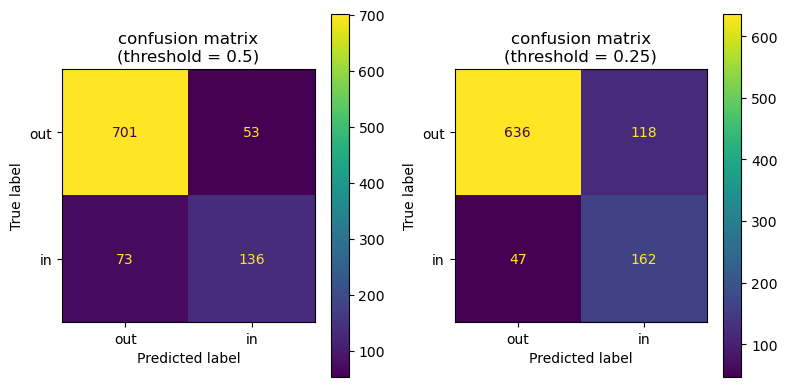

In [279]:
mlp_test_preds_05 = (mlp_test_proba >= 0.5).astype(int)  # binary at default threshold
mlp_test_preds_025 = (mlp_test_proba >= 0.25).astype(int)  # binary at default threshold

# Plot confusion matrix
fig, ax = plt.subplots(1,2, figsize=(8,4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test_scope, mlp_test_preds_05),
    display_labels=['out', 'in']
).plot(ax=ax[0])
ax[0].set_title('confusion matrix\n(threshold = 0.5)')

ConfusionMatrixDisplay(
    confusion_matrix(y_test_scope, mlp_test_preds_025),
    display_labels=['out', 'in']
).plot(ax=ax[1])
ax[1].set_title('confusion matrix\n(threshold = 0.25)')


plt.tight_layout()
plt.savefig('Plots/SciBERT_MLP_ConfusionMatrix.png', dpi=150, bbox_inches='tight')
plt.show()

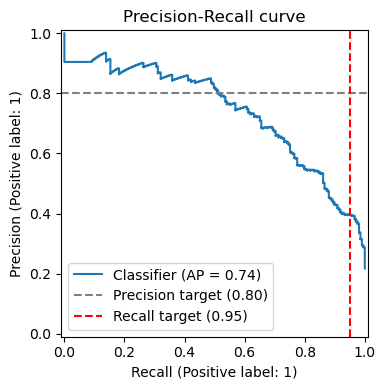

In [280]:
# Plot precision-recall curve
fig, ax = plt.subplots(figsize=(4,4))
PrecisionRecallDisplay.from_predictions(
    y_test_scope, mlp_test_proba, ax=ax
)
ax.axhline(0.80, color='grey',  linestyle='--', label='Precision target (0.80)')
ax.axvline(0.95, color='red',   linestyle='--', label='Recall target (0.95)')
ax.set_title('Precision-Recall curve')
ax.legend()
plt.tight_layout()
plt.savefig('Plots/SciBERT_MLP_Precision-Recall.png', dpi=150, bbox_inches='tight')
plt.show()

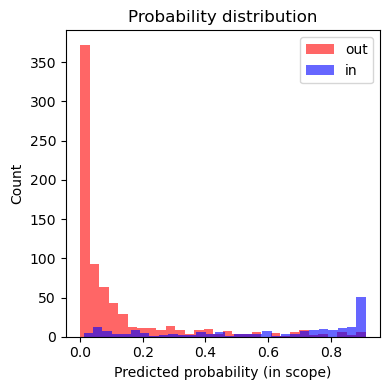

In [281]:
fig, ax = plt.subplots(figsize=(4,4))
ax.hist(mlp_test_proba[y_test_scope == 0], bins=30, alpha=0.6, 
        color='red',  label='out')
ax.hist(mlp_test_proba[y_test_scope == 1], bins=30, alpha=0.6, 
        color='blue', label='in')
ax.set_xlabel('Predicted probability (in scope)')
ax.set_ylabel('Count')
ax.set_title('Probability distribution')
ax.legend()
plt.tight_layout()
plt.savefig('Plots/SciBERT_MLP_ProbabilityDistribution.png', dpi=150, bbox_inches='tight')
plt.show()

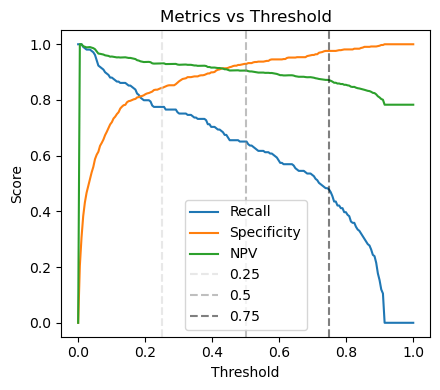

In [307]:
# Plot recall, specificity and npv against different thresholds
thresholds_range = np.linspace(0, 1, 200)

sensitivity = []  # recall / TPR
specificity = []  # TNR
npv         = []  # TN / (TN + FN)

for t in thresholds_range:
    test_pred = (mlp_test_proba >= t).astype(int)
    
    TP = ((test_pred == 1) & (y_test_scope == 1)).sum()
    TN = ((test_pred == 0) & (y_test_scope == 0)).sum()
    FP = ((test_pred == 1) & (y_test_scope == 0)).sum()
    FN = ((test_pred == 0) & (y_test_scope == 1)).sum()
    
    sensitivity.append(TP / (TP + FN) if (TP + FN) > 0 else 0)
    specificity.append(TN / (TN + FP) if (TN + FP) > 0 else 0)
    npv.append(        TN / (TN + FN) if (TN + FN) > 0 else 0)

fig, ax = plt.subplots(figsize=(4.5, 4))

# Plot 1: all three metrics vs threshold
ax.plot(thresholds_range, sensitivity, label='Recall')
ax.plot(thresholds_range, specificity, label='Specificity')
ax.plot(thresholds_range, npv,         label='NPV')
ax.axvline(0.25, color='lightgrey', linestyle='--', alpha=0.5, label='0.25')
ax.axvline(0.5, color='grey', linestyle='--', alpha=0.5, label='0.5')
ax.axvline(0.75, color='black', linestyle='--', alpha=0.5, label='0.75')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Metrics vs Threshold')
ax.legend()

plt.tight_layout()
plt.savefig('Plots/SciBERT_MLP_MetricsThreshold.png', dpi=150, bbox_inches='tight')
plt.show()

In [349]:
# Metrics for threshold T
T = 0.05
pred = (mlp_test_proba >= T).astype(int)
    
TP = ((pred == 1) & (y_test_scope == 1)).sum()
TN = ((pred == 0) & (y_test_scope == 0)).sum()
FP = ((pred == 1) & (y_test_scope == 0)).sum()
FN = ((pred == 0) & (y_test_scope == 1)).sum()

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)
npv = TN / (TN + FN) 

p, c = np.unique(pred, return_counts=True)

print(f"With a threshold of {T}, we remove {round(c[0] / (c[0] + c[1]) * 100, 2)}% of all entries and loose ~{round(FN / len(pred) * 100,2)}% of in scope cases.")
print(f"Sensitivity: {sensitivity}, Specificity: {specificity}, NPV: {npv}")

With a threshold of 0.05, we remove 46.73% of all entries and loose ~0.83% of in scope cases.
Sensitivity: 0.9617224880382775, Specificity: 0.5862068965517241, NPV: 0.9822222222222222


#### Manual check of borderline cases

In [ ]:
borderline = [
    "pub.1124225534", "pub.1124559012", "pub.1124752776", "pub.1125171104",
    "pub.1125711840", "pub.1125900690", "pub.1126016358", "pub.1126776207",
    "pub.1127784762", "pub.1128699237", "pub.1128910615", "pub.1128979198",
    "pub.1129074092", "pub.1129500680", "pub.1129501629", "pub.1129666565",
    "pub.1129921272", "pub.1130005418", "pub.1130094430", "pub.1130433231",
    "pub.1130539219", "pub.1131172589", "pub.1131480945", "pub.1131844732",
    "pub.1131885381"
]

In [350]:
# Combine tables with probabilities and predictions for threshold T
T = 0.05

d_train = y_train.copy()
d_train['proba'] = mlp_probs
d_train[f'pred_{T}'] = (d_train['proba'] >= T).astype(int)

d_test = y_test.copy()
d_test['proba'] = mlp_test_proba
d_test[f'pred_{T}'] = (d_test['proba'] >= T).astype(int)

d = pd.concat([d_train, d_test])

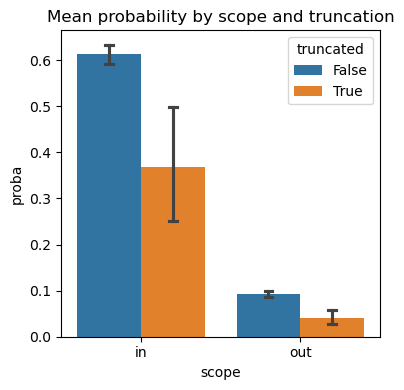

In [324]:
# Check wether truncation during embedding makes a difference
d.groupby(['scope', 'truncated'])['proba'].mean()

fig, ax = plt.subplots(figsize=(4, 4))
sns.barplot(data=d, x='scope', y='proba', hue='truncated',  capsize=0.1, ax=ax)
ax.set_title('Mean probability by scope and truncation')
plt.tight_layout()
plt.savefig('Plots/SciBERT_MLP_T005_truncation.png', dpi=150, bbox_inches='tight')
plt.show()

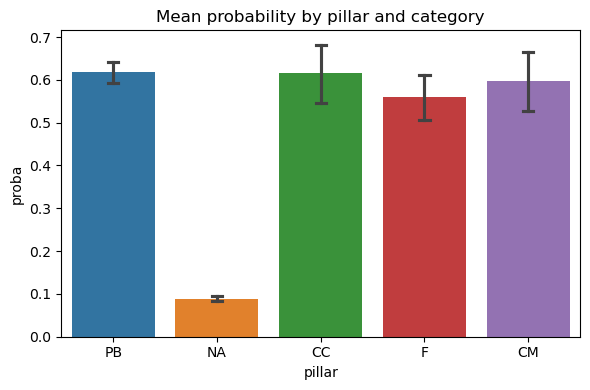

In [325]:
# Check whether different pillars/categories make a difference
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=d, x='pillar', y='proba', hue='pillar', capsize=0.1, ax=ax)
ax.set_title('Mean probability by pillar and category')
plt.tight_layout()
plt.savefig('Plots/SciBERT_MLP_Probabilities_Pillar.png', dpi=150, bbox_inches='tight')
plt.show()

In [342]:
mlp_fn = d[(d['scope']=='in')  & (d['pred_0.05']==0)]

### False Negatives across models

In [365]:
fn = pd.concat([lr_fn[['id', 'title', 'abstract', 'pillar', 'research_category', 'truncated']], 
                svc_fn[['id', 'title', 'abstract', 'pillar', 'research_category', 'truncated']], 
                mlp_fn[['id', 'title', 'abstract', 'pillar', 'research_category', 'truncated']]])

fn = fn.drop_duplicates(subset='id')

fn['LR'] = fn['id'].isin(lr_fn['id'])
fn['SVC'] = fn['id'].isin(svc_fn['id'])
fn['MLP'] = fn['id'].isin(mlp_fn['id'])

fn.to_csv('SciBERT_FalseNegatives.csv')

### Close connection

In [48]:
db.close()